In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [24]:
# Definiendo los valores de entrada y salida

celsius =np.array([-40, -10, 0, 8, 15, 22, 38], dtype=float)
fahrenheit = np.array([-40, 14, 32, 46, 59, 72, 100], dtype=float)

In [ ]:

# Keras permite el diseño de toda la red y en este caso su función Dense() reailiza todas las conexiones posibles entre capas
# Se define el número de entradas (1) para este este
# En el modelo se describe como va a funcionar la red neuronal

# capa = tf.keras.layers.Dense(units=1, input_shape=[1]) # define una sola neurona para el entrenamiento
# modelo = tf.keras.Sequential([capa])

# Agregando más capas a la red
# Para este nuevo modeloa se define:
# 1 neurona de entrada
# 3 neuronas en la 1ra capa oculta
# 3 neuronas en la 3ra capa oculta 
# 1 neurona en la capa de salida
# Finalmente se vincula todo en el modelo Sequential

oculta1 = tf.keras.layers.Dense(units=3, input_shape=[1]) 
oculta2 = tf.keras.layers.Dense(units=3)
salida = tf.keras.layers.Dense(units=1)
modelo = tf.keras.Sequential([oculta1, oculta2, salida])


c:\Users\Bremdows\anaconda3\envs\tensral\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(0.1),
    loss='mean_squared_error'
)

In [27]:
historial = modelo.fit(celsius, fahrenheit, epochs=1000, verbose=False)

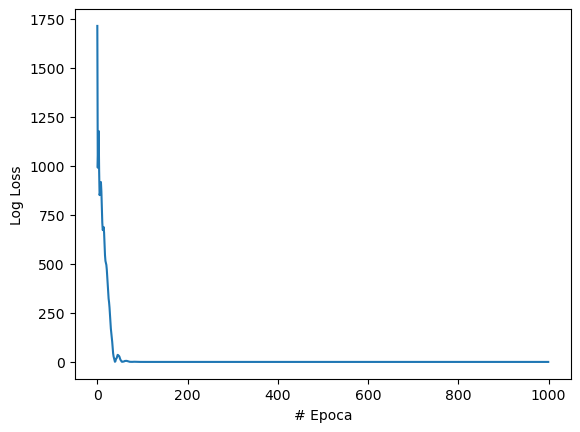

In [28]:

plt.xlabel("# Epoca")
plt.ylabel("Log Loss")
plt.plot(historial.history["loss"])

In [29]:
print("Prediciendo un valor")

value_predict = np.array([[100]])
resultado = modelo.predict(value_predict)

print(f"{value_predict} C° equivale a {resultado} F")

Prediciendo un valor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
[[100]] C° equivale a [[211.74744]] F


In [32]:
# pesos en 1.79 y el sesgo en 31.930372

print("variables internas del modelo")
print(oculta1.get_weights())
print(oculta2.get_weights())
print(salida.get_weights())


variables internas del modelo
[array([[ 0.3171773 ,  0.55991256, -0.00545221]], dtype=float32), array([3.804916 , 3.8846145, 0.7967098], dtype=float32)]
[array([[-1.0019898 , -0.44882634,  0.6759917 ],
       [ 0.33096623, -0.94238263,  1.1673816 ],
       [ 0.4124404 , -0.47199437,  0.21650769]], dtype=float32), array([-3.3983958, -3.9344487,  3.8882911], dtype=float32)]
[array([[-1.0481257 ],
       [-0.91166675],
       [ 1.2092377 ]], dtype=float32), array([3.7581155], dtype=float32)]
